The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Graphs

The next three chapters are about systems made up of components and connections between components. For example, in a social network, the components are people and connections represent friendships, business relationships, etc. In an ecological food web, the components are species and the connections represent predator-prey relationships.

In this chapter, I introduce NetworkX, a Python package for building models of these systems. We start with the Erdős-Rényi model, which has interesting mathematical properties. In the next chapter we move on to models that are more useful for explaining real-world systems.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap02.ipynb).

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')

In [3]:
from utils import decorate, savefig

# Set the random seed so the notebook 
# produces the same results every time.
np.random.seed(17)

In [4]:
# make a directory for figures
!mkdir -p figs

In [5]:
# node colors for drawing networks
colors = sns.color_palette('pastel', 5)
#sns.palplot(colors)
sns.set_palette(colors)

## What is a graph?

To most people a "graph" is a visual representation of data, like a bar chart or a plot of stock prices over time. That's not what this chapter is about.

In this chapter, a **graph** is a representation of a system that contains discrete, interconnected elements. The elements are represented by **nodes** — also called **vertices** – and the interconnections are represented by **edges**.

For example, you could represent a road map with a node for each city and an edge for each road between cities. Or you could represent a social network using a node for each person, with an edge between two people if they are friends.

In some graphs, edges have attributes like length, cost, or weight. For example, in a road map, the length of an edge might represent distance between cities or travel time. In a social network there might be different kinds of edges to represent different kinds of relationships: friends, business associates, etc.

Edges may be **directed** or **undirected**, depending on whether the relationships they represent are asymmetric or symmetric. In a road map, you might represent a one-way street with a directed edge and a two-way street with an undirected edge. In some social networks, like Facebook, friendship is symmetric: if $A$ is friends with $B$ then $B$ is friends with $A$. But on Twitter, for example, the "follows" relationship is not symmetric; if $A$ follows $B$, that doesn't imply that $B$ follows $A$. So you might use undirected edges to represent a Facebook network and directed edges for Twitter.

Graphs have interesting mathematical properties, and there is a branch of mathematics called **graph theory** that studies them.

Graphs are also useful, because there are many real world problems that can be solved using **graph algorithms**. For example, Dijkstra's shortest path algorithm is an efficient way to find the shortest path from a node to all other nodes in a graph. A **path** is a sequence of nodes with an edge between each consecutive pair.

Graphs are usually drawn with squares or circles for nodes and lines for edges. In the next section, we'll draw a directed graph that represents a social network, and an undirected graph that represents driving times between cities.

## NetworkX

To represent graphs, we'll use a package called NetworkX, which is the most commonly used network library in Python. You can read more about it at <https://thinkcomplex.com/netx>, but I'll explain it as we go along.

We can create a directed graph by importing NetworkX (usually imported as `nx`) and instantiating `nx.DiGraph`:

In [6]:
G = nx.DiGraph()

At this point, `G` is a `DiGraph` object that contains no nodes and no edges. We can add nodes using the `add_node` method:

In [7]:
G.add_node('Alice')
G.add_node('Bob')
G.add_node('Cate')

Now we can use the `nodes` method to get a list of nodes:

In [8]:
list(G.nodes())

['Alice', 'Bob', 'Cate']

The `nodes` method returns a `NodeView`, which can be used in a for loop or, as in this example, used to make a list.

Adding edges works pretty much the same way:

In [9]:
G.add_edge('Alice', 'Bob')
G.add_edge('Alice', 'Cate')
G.add_edge('Bob', 'Alice')
G.add_edge('Bob', 'Cate')

And we can use `edges` to get the list of edges:

In [10]:
list(G.edges())

[('Alice', 'Bob'), ('Alice', 'Cate'), ('Bob', 'Alice'), ('Bob', 'Cate')]

NetworkX provides several functions for drawing graphs; `draw_circular` arranges the nodes in a circle and connects them with edges:

Saving figure to file figs/chap02-1


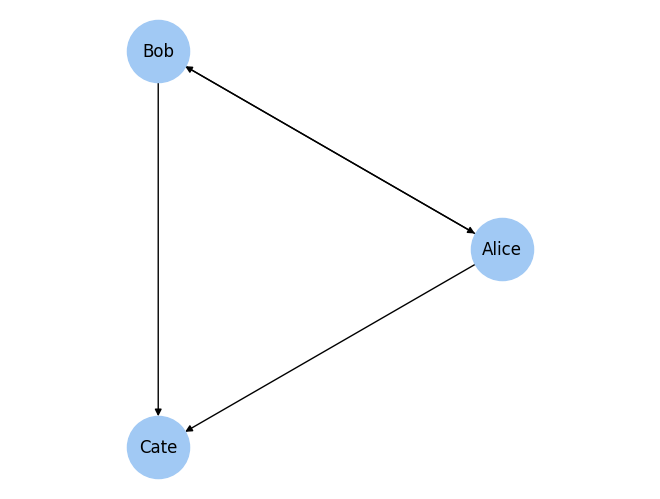

In [11]:
nx.draw_circular(G,
                 node_color='C0',
                 node_size=2000, 
                 with_labels=True)
plt.axis('equal')
savefig('figs/chap02-1')

This directed graph might represent three people who follow each other on Twitter. The arrow indicates the direction of the relationship. In this example, Alice and Bob follow each other, both follow Cate, and Cate follows no one.

The option `with_labels` causes the nodes to be labeled; in the next example we'll see how to label the edges.

**Exercise:**  Add another node and a few more edges and draw the graph again.

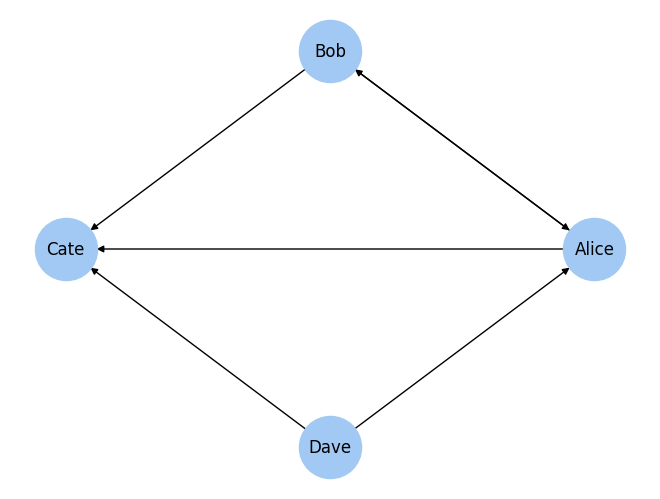

In [12]:
# Solution

G.add_edge('Dave', 'Alice')
G.add_edge('Dave', 'Cate')
nx.draw_circular(G,
                 node_color='C0',
                 node_size=2000, 
                 with_labels=True)

The second example is an undirected graph that represents four cities in the northeast United States and the driving times between them. I start with a dictionary that maps from each city name to its approximate longitude and latitude:

In [13]:
positions = dict(Albany=(-74, 43),
                 Boston=(-71, 42),
                 NYC=(-74, 41),
                 Philly=(-75, 40))

positions['Albany']

(-74, 43)

Since this is an undirected graph, I instantiate `nx.Graph`. Then I can use `add_nodes_from` to iterate the keys of `positions` and add them as nodes:

In [14]:
G = nx.Graph()
G.add_nodes_from(positions)
G.nodes()

NodeView(('Albany', 'Boston', 'NYC', 'Philly'))

Next I'll make a dictionary that maps from each edge to the corresponding driving time:

In [15]:
drive_times = {('Albany', 'Boston'): 3,
               ('Albany', 'NYC'): 4,
               ('Boston', 'NYC'): 4,
               ('NYC', 'Philly'): 2}

Now I can use `add_edges_from`, which iterates the keys of `drive_times` and adds them as edges:

In [16]:
G.add_edges_from(drive_times)
G.edges()

EdgeView([('Albany', 'Boston'), ('Albany', 'NYC'), ('Boston', 'NYC'), ('NYC', 'Philly')])

Instead of `draw_circular`, which arranges the nodes in a circle, I'll use `draw`, which takes the position dictionary as the second parameter. `draw` uses `positions` to determine the locations of the nodes.

To add the edge labels, we use `draw_networkx_edge_labels`. The `edge_labels` parameter expects a dictionary that maps from each pair of nodes to a label; in this case, the labels are driving times between cities.

Saving figure to file figs/chap02-2


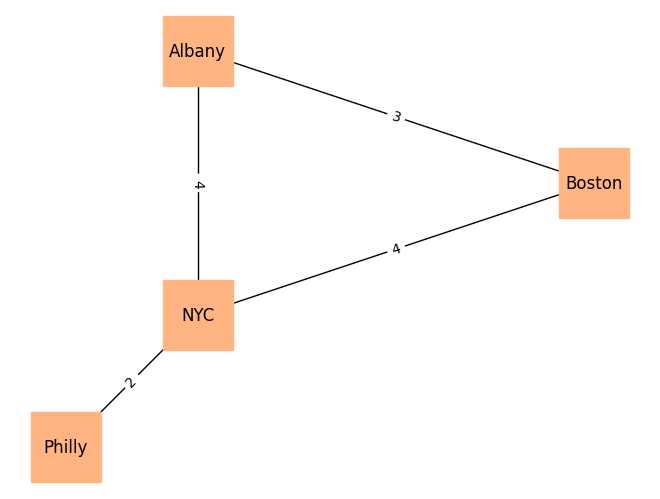

In [17]:
nx.draw(G, positions, 
        node_color='C1', 
        node_shape='s', 
        node_size=2500, 
        with_labels=True)

nx.draw_networkx_edge_labels(G, positions, 
                             edge_labels=drive_times)

plt.axis('equal')
savefig('figs/chap02-2')

The labels on the edges indicate driving time in hours. In this example the placement of the nodes corresponds roughly to the geography of the cities, but in general the layout of a graph is arbitrary.

In both of these examples, the nodes are strings, but in general they can be any hashable type.

**Exercise:**  Add another city and at least one edge.

(np.float64(-76.525),
 np.float64(-70.475),
 np.float64(39.685),
 np.float64(43.315))

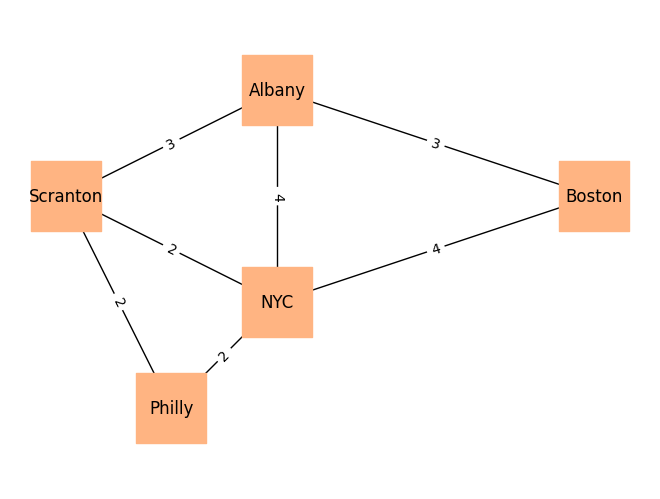

In [18]:
# Solution

positions['Scranton'] = (-76, 42)
G.add_node('Scranton')

drive_times.update({('Scranton', 'Albany'): 3,
                    ('Scranton', 'NYC'): 2,
                    ('Scranton', 'Philly'): 2})

G.add_edges_from(drive_times)

nx.draw(G, positions, 
        node_color='C1', 
        node_shape='s', 
        node_size=2500, 
        with_labels=True)

nx.draw_networkx_edge_labels(G, positions, 
                             edge_labels=drive_times)

plt.axis('equal')

## Random graphs

A random graph is just what it sounds like: a graph with nodes and edges generated at random. Of course, there are many random processes that can generate graphs, so there are many kinds of random graphs.

One of the more interesting kinds is the Erdős-Rényi model, studied by Paul Erdős and Alfréd Rényi in the 1960s.

An Erdős-Rényi graph (ER graph) is characterized by two parameters: $n$ is the number of nodes and $p$ is the probability that there is an edge between any two nodes. See <https://thinkcomplex.com/er>.

Erdős and Rényi studied the properties of these random graphs; one of their surprising results is the existence of abrupt changes in the properties of random graphs as random edges are added.

One of the properties that displays this kind of transition is connectivity. An undirected graph is **connected** if there is a path from every node to every other node.

In an ER graph, the probability that the graph is connected is very low when $p$ is small and nearly 1 when $p$ is large. Between these two regimes, there is a rapid transition at a particular value of $p$, denoted $p^*$.

Erdős and Rényi showed that this critical value is $p^* = (\ln n) / n$, where $n$ is the number of nodes. A random graph, $G(n, p)$, is unlikely to be connected if $p < p^*$ and very likely to be connected if $p > p^*$.

To test this claim, we'll develop algorithms to generate random graphs and check whether they are connected.

## Generating graphs

I'll start by generating a **complete** graph, which is a graph where every node is connected to every other.

Here's a generator function that takes a list of nodes and enumerates all distinct pairs. If you are not familiar with generator functions, you can read about them at <https://thinkcomplex.com/gen>.

In [19]:
def all_pairs(nodes):
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i < j:
                yield u, v

We can use `all_pairs` to construct a complete graph:

In [20]:
def make_complete_graph(n):
    G = nx.Graph()
    nodes = range(n)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_pairs(nodes))
    return G

`make_complete_graph` takes the number of nodes, `n`, and returns a new `Graph` with `n` nodes and edges between all pairs of nodes.

The following code makes a complete graph with 10 nodes:

In [21]:
complete = make_complete_graph(10)
complete.number_of_nodes()

10

And here's what it looks like.

Saving figure to file figs/chap02-3


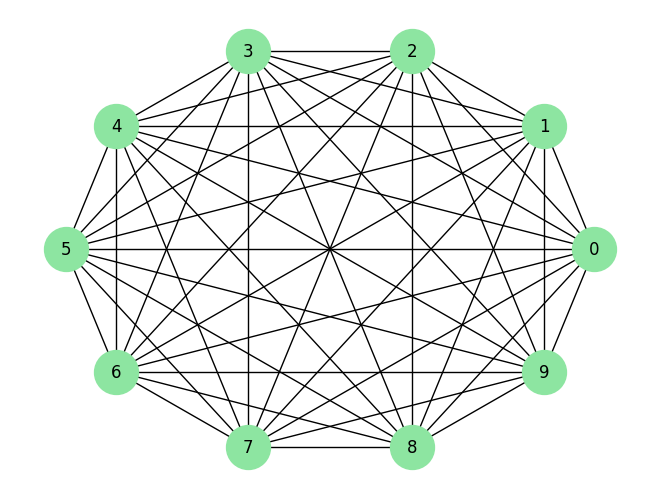

In [22]:
nx.draw_circular(complete, 
                 node_color='C2', 
                 node_size=1000, 
                 with_labels=True)
savefig('figs/chap02-3')

Soon we will modify this code to generate ER graphs, but first we'll develop functions to check whether a graph is connected.

**Exercise:** Make and draw a complete directed graph with 5 nodes.

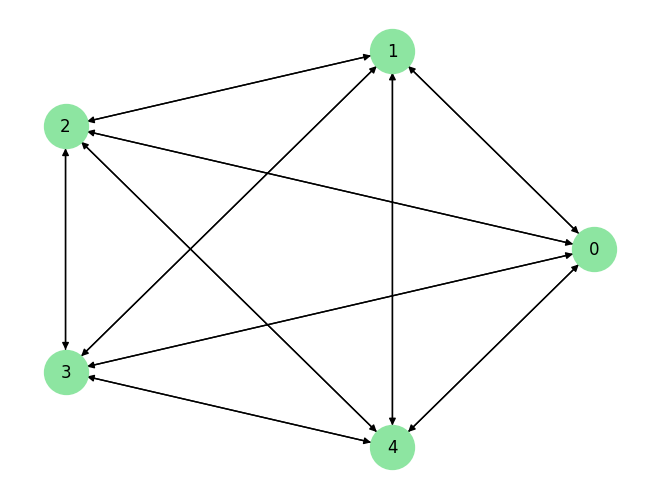

In [23]:
# Solution

def all_directed_pairs(nodes):
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i != j:
                yield u, v
                
def make_complete_digraph(n):
    G = nx.DiGraph()
    nodes = range(n)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_directed_pairs(nodes))
    return G

complete_digraph = make_complete_digraph(5)

nx.draw_circular(complete_digraph, 
                 node_color='C2', 
                 node_size=1000, 
                 with_labels=True)

## Connected graphs

A graph is **connected** if there is a path from every node to every other node (see <https://thinkcomplex.com/conn>).

For many applications involving graphs, it is useful to check whether a graph is connected. Fortunately, there is a simple algorithm that does it.

You can start at any node and check whether you can reach all other nodes. If you can reach a node, $v$, you can reach any of the **neighbors** of $v$, which are the nodes connected to $v$ by an edge.

The `Graph` class provides a method called `neighbors` that returns a list of neighbors for a given node. For example, in the complete graph we generated in the previous section:

In [24]:
list(complete.neighbors(0))

[1, 2, 3, 4, 5, 6, 7, 8, 9]

Suppose we start at node $s$. We can mark $s$ as "seen" and mark its neighbors. Then we mark the neighbor's neighbors, and their neighbors, and so on, until we can't reach any more nodes. If all nodes are seen, the graph is connected.

Here's what that looks like in Python:

In [25]:
def reachable_nodes(G, start):
    seen = set()
    stack = [start]
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            stack.extend(G.neighbors(node))
    return seen

`reachable_nodes` takes a `Graph` and a starting node, ` start`, and returns the set of nodes that can be reached from ` start`.

Initially the set, `seen`, is empty, and we create a list called `stack` that keeps track of nodes we have discovered but not yet processed. Initially the stack contains a single node, `start`.

Now, each time through the loop, we:

1.  Remove one node from the stack.

2.  If the node is already in `seen`, we go back to Step 1.

3.  Otherwise, we add the node to `seen` and add its neighbors to the stack.

When the stack is empty, we can't reach any more nodes, so we break out of the loop and return `seen`.

As an example, we can find all nodes in the complete graph that are reachable from node 0:

In [26]:
reachable_nodes(complete, 0)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

Initially, the stack contains node 0 and `seen` is empty. The first time through the loop, node 0 is added to `seen` and all the other nodes are added to the stack (since they are all neighbors of node 0).

The next time through the loop, `pop` returns the last element in the stack, which is node 9. So node 9 gets added to `seen` and its neighbors get added to the stack.

Notice that the same node can appear more than once in the stack; in fact, a node with $k$ neighbors will be added to the stack $k$ times. Later, we will look for ways to make this algorithm more efficient.

We can use `reachable_nodes` to write `is_connected`:

In [27]:
def is_connected(G):
    start = next(iter(G))
    reachable = reachable_nodes(G, start)
    return len(reachable) == len(G)

`is_connected` chooses a starting node by making a node iterator and choosing the first element. Then it uses `reachable` to get the set of nodes that can be reached from `start`. If the size of this set is the same as the size of the graph, that means we can reach all nodes, which means the graph is connected.

A complete graph is, not surprisingly, connected:

In [28]:
is_connected(complete)

True

In the next section we will generate ER graphs and check whether they are connected.

**Exercise:** What do you think it means for a directed graph to be connected?  Write a function that checks whether a directed graph is connected.

In [29]:
# Solution

"""According to [Wolfram MathWorld](http://mathworld.wolfram.com/ConnectedDigraph.html)

"There are two distinct notions of connectivity in a directed graph. A directed graph is 
weakly connected if there is an undirected path between any pair of vertices, 
and strongly connected if there is a directed path between every pair of vertices"

We'll check for strong connectedness.

"""

def directed_reachable_nodes(G, start):
    seen = set()
    stack = [start]
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            stack.extend(G.successors(node))
    return seen

def digraph_is_connected(G):
    for start in G:
        reachable = directed_reachable_nodes(G, start)
        if len(reachable) < len(G):
            return False
    return True
        
complete_digraph = make_complete_digraph(5)
digraph_is_connected(complete_digraph)

True

## Generating ER graphs

The ER graph $G(n, p)$ contains $n$ nodes, and each pair of nodes is connected by an edge with probability $p$. Generating an ER graph is similar to generating a complete graph.

The following generator function enumerates all possible edges and chooses which ones should be added to the graph:

In [30]:
def random_pairs(nodes, p):
    for edge in all_pairs(nodes):
        if flip(p):
            yield edge

`random_pairs` uses `flip`:

In [31]:
def flip(p):
    return np.random.random() < p

This is the first example we're seen that uses NumPy. Following convention, I import `numpy` as `np`. NumPy provides a module named `random`, which provides a method named `random`, which returns a number between 0 and 1, uniformly distributed.

So `flip` returns `True` with the given probability, `p`, and `False` with the complementary probability, `1-p`.

Finally, `make_random_graph` generates and returns the ER graph $G(n, p)$:

In [32]:
def make_random_graph(n, p):
    G = nx.Graph()
    nodes = range(n)
    G.add_nodes_from(nodes)
    G.add_edges_from(random_pairs(nodes, p))
    return G

`make_random_graph` is almost identical to `make_complete_graph`; the only difference is that it uses `random_pairs` instead of `all_pairs`.

Here's an example with `n=10` and `p=0.3`:

In [33]:
np.random.seed(10)

random_graph = make_random_graph(10, 0.3)
len(random_graph.edges())

12

And here's what it looks like:

Saving figure to file figs/chap02-4


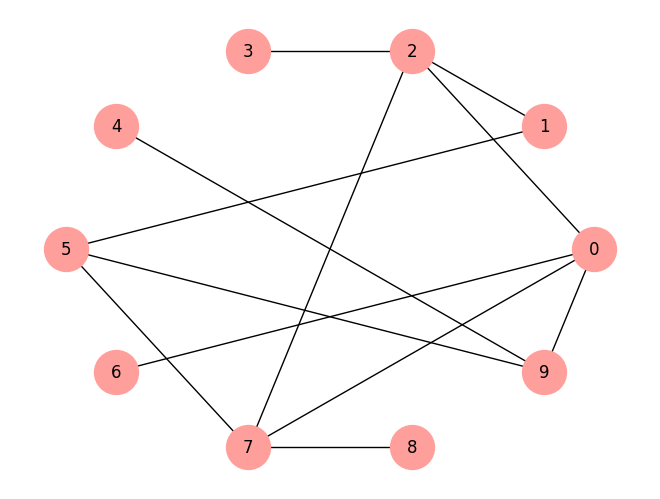

In [34]:
nx.draw_circular(random_graph, 
                 node_color='C3', 
                 node_size=1000, 
                 with_labels=True)
savefig('figs/chap02-4')

This graph turns out to be connected: starting from node 0, we can reach all nodes.

In [35]:
reachable_nodes(random_graph, 0)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In fact, most ER graphs with $n=10$ and $p=0.3$ are connected. But if we generate a random graph with a low value of `p`, it's not:

In [36]:
random_graph = make_random_graph(10, 0.1)
len(random_graph.edges())

6

In [37]:
is_connected(random_graph)

False

In the next section, we'll see how many are connected.

## Probability of connectivity

For given values of $n$ and $p$, we would like to know the probability that $G(n, p)$ is connected. We can estimate it by generating a large number of random graphs and counting how many are connected. This function takes `n` and `p`, generates `iters` graphs, and returns the fraction of them that are connected.

In [38]:
# version with a for loop

def prob_connected(n, p, iters=100):
    count = 0
    for i in range(iters):
        random_graph = make_random_graph(n, p)
        if is_connected(random_graph):
            count += 1
    return count/iters

Here's a more concise version:

In [39]:
# version with a list comprehension

def prob_connected(n, p, iters=100):
    tf = [is_connected(make_random_graph(n, p))
          for i in range(iters)]
    return np.mean(tf)

The parameters `n` and `p` are passed along to `make_random_graph`; `iters` is the number of random graphs we generate.

This function uses a list comprehension; if you are not familiar with this feature, you can read about it at <https://thinkcomplex.com/comp>.

The result, `tf`, is a list of boolean values: `True` for each graph that's connected and `False` for each one that's not.

`np.mean` is a NumPy function that computes the mean of this list, treating `True` as 1 and `False` as 0. The result is the fraction of random graphs that are connected.

In [40]:
np.random.seed(17)

n = 10
prob_connected(n, 0.23, iters=10000)

np.float64(0.3393)

I chose $0.23$ because it is close to the critical value where the probability of connectivity goes from near 0 to near 1. According to Erdős and Rényi, $p^* = \ln n / n = 0.23$.

In [41]:
pstar = np.log(n) / n
pstar

np.float64(0.23025850929940458)

We can get a clearer view of the transition by estimating the probability of connectivity for a range of values of $p$:

In [42]:
ps = np.logspace(-1.3, 0, 11)
ps

array([0.05011872, 0.0676083 , 0.09120108, 0.12302688, 0.16595869,
       0.22387211, 0.30199517, 0.40738028, 0.54954087, 0.74131024,
       1.        ])

The NumPy function `logspace` returns an array of 11 values from $10^{-1.3}$ to $10^0 = 1$, equally spaced on a logarithmic scale.

For each value of `p` in the array, we compute the probability that a graph with parameter `p` is connected and store the results in `ys`. I'll estimate the probabilities with `iters=1000`.

In [43]:
ys = [prob_connected(n, p, 1000) for p in ps]

for p, y in zip(ps, ys):
    print(p, y)

0.05011872336272722 0.0
0.06760829753919818 0.0
0.09120108393559097 0.004
0.12302687708123815 0.016
0.16595869074375605 0.109
0.22387211385683395 0.346
0.3019951720402016 0.664
0.40738027780411273 0.899
0.5495408738576245 0.989
0.7413102413009173 1.0
1.0 1.0


The following figure shows the results, with a vertical line at the computed critical value, $p^* = 0.23$.

Saving figure to file figs/chap02-5


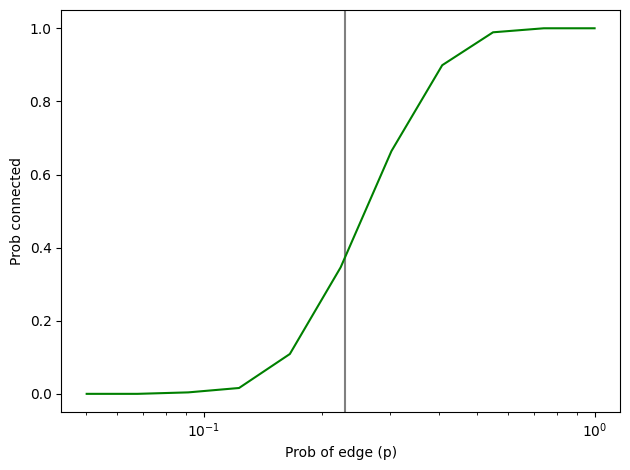

In [44]:
plt.axvline(pstar, color='gray')
plt.plot(ps, ys, color='green')
decorate(xlabel='Prob of edge (p)',
                 ylabel='Prob connected',
                 xscale='log')

savefig('figs/chap02-5')

As expected, the transition from 0 to 1 occurs near the critical value.

We can run the same analysis for a few more values of `n`. The following figure shows the results, with vertical lines at the critical values.

300


100


30


Saving figure to file figs/chap02-6


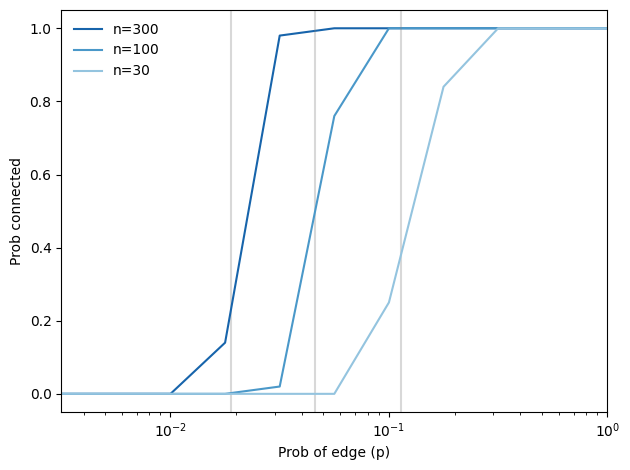

In [45]:
ns = [300, 100, 30]
ps = np.logspace(-2.5, 0, 11)

sns.set_palette('Blues_r', 4)
for n in ns:
    print(n)
    pstar = np.log(n) / n
    plt.axvline(pstar, color='gray', alpha=0.3)

    ys = [prob_connected(n, p) for p in ps]
    plt.plot(ps, ys, label='n=%d' % n)

decorate(xlabel='Prob of edge (p)',
         ylabel='Prob connected',
         xscale='log', 
         xlim=[ps[0], ps[-1]],
         loc='upper left')

savefig('figs/chap02-6')

As $n$ increases, the critical value gets smaller and the transition gets more abrupt.

These experimental results are consistent with the analytic results Erdős and Rényi presented in their papers.

## Analysis of graph algorithms

Earlier in this chapter I presented an algorithm for checking whether a graph is connected; in the next few chapters, we will see other graph algorithms. Along the way, we will analyze the performance of those algorithms, figuring out how their run times grow as the size of the graphs increases.

If you are not already familiar with analysis of algorithms, you might want to read Appendix B of *Think Python, 2nd Edition*, at <https://thinkcomplex.com/tp2>.

The order of growth for graph algorithms is usually expressed as a function of $n$, the number of vertices (nodes), and $m$, the number of edges.

As an example, let's analyze `reachable_nodes` from the "Connected graphs" section:

```
def reachable_nodes(G, start):
    seen = set()
    stack = [start]
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            stack.extend(G.neighbors(node))
    return seen
```

Each time through the loop, we pop a node off the stack; by default, `pop` removes and returns the last element of a list, which is a constant time operation.

Next we check whether the node is in `seen`, which is a set, so checking membership is constant time.

If the node is not already in `seen`, we add it, which is constant time, and then add the neighbors to the stack, which is linear in the number of neighbors.

To express the run time in terms of $n$ and $m$, we can add up the total number of times each node is added to `seen` and `stack`.

Each node is only added to `seen` once, so the total number of additions is $n$.

But nodes might be added to `stack` many times, depending on how many neighbors they have. If a node has $k$ neighbors, it is added to `stack` $k$ times. Of course, if it has $k$ neighbors, that means it is connected to $k$ edges.

So the total number of additions to `stack` is the total number of edges, $m$, doubled because we consider every edge twice.

Therefore, the order of growth for this function is $O(n+ m)$, which is a convenient way to say that the run time grows in proportion to either $n$ or $m$, whichever is bigger.

If we know the relationship between $n$ and $m$, we can simplify this expression. For example, in a complete graph the number of edges is $n(n-1)/2$, which is in $O(n^2)$. So for a complete graph, `reachable_nodes` is quadratic in $n$.

## Exercises

**Exercise:** In the "Analysis of graph algorithms" section we analyzed the performance of `reachable_nodes` and classified it in $O(n + m)$, where $n$ is the number of nodes and $m$ is the number of edges.  Continuing the analysis, what is the order of growth for `is_connected`?

    def is_connected(G):
        start = list(G)[0]
        reachable = reachable_nodes(G, start)
        return len(reachable) == len(G)


In [46]:
# Solution

"""Creating an iterator and getting the first element are constant time operations.
Calling `reachable_nodes` is $O(n+m)$.  Getting the length of a set and a graph are 
constant time (but even if they were linear in $n$, it wouldn't matter).  So the 
total for `is_connected` is $O(n+m)$.""";

**Exercise:** In my implementation of `reachable_nodes`, you might be bothered by the apparent inefficiency of adding *all* neighbors to the stack without checking whether they are already in `seen`.  Write a version of this function that checks the neighbors before adding them to the stack.  Does this "optimization" change the order of growth?  Does it make the function faster?

In [47]:
def reachable_nodes_precheck(G, start):
    # FILL THIS IN
    return []

In [48]:
# Solution

"""Checking the nodes before putting them on the stack does not affect the order 
of growth; we have to perform the same number of checks either way.  But it might 
be a little faster because it avoids the overhead of adding and removing nodes 
from the stack over and over."""

def reachable_nodes_precheck(G, start):
    seen = set()
    stack = [start]
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            neighbors = set(G[node]) - seen
            stack.extend(neighbors)
    return seen

complete = make_complete_graph(100)

In [49]:
%timeit len(reachable_nodes(complete, 0))

620 μs ± 14.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [50]:
%timeit len(reachable_nodes_precheck(complete, 0))

702 μs ± 13.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


**Exercise:** There are actually two kinds of ER graphs.  The one we generated in this chapter, $G(n, p)$, is characterized by two parameters, the number of nodes and the probability of an edge between nodes.

An alternative definition, denoted $G(n, m)$, is also characterized by two parameters: the number of nodes, $n$, and the number of edges, $m$.  Under this definition, the number of edges is fixed, but their location is random.

Repeat the experiments we did in this chapter using this alternative definition.  Here are a few suggestions for how to proceed:

1. Write a function called `m_pairs` that takes a list of nodes and the number of edges, $m$, and returns a random selection of $m$ edges.  A simple way to do that is to generate a list of all possible edges and use `random.sample`.

2. Write a function called `make_m_graph` that takes $n$ and $m$ and returns a random graph with $n$ nodes and $m$ edges.

3. Make a version of `prob_connected` that uses `make_m_graph` instead of `make_random_graph`.

4. Compute the probability of connectivity for a range of values of $m$.

How do the results of this experiment compare to the results using the first type of ER graph?

1.0444444444444445
1.0454545454545454
1.0465116279069768
1.0476190476190477
1.048780487804878
1.05
1.0512820512820513
1.0526315789473684
1.054054054054054
1.0555555555555556
1.0571428571428572
1.0588235294117647
1.0606060606060606
1.0625
1.064516129032258
1.0666666666666667
1.0689655172413792
1.0714285714285714
1.0740740740740742
1.0769230769230769
1.08
1.0833333333333333
1.0869565217391304
1.0909090909090908
1.0952380952380953
1.1
1.105263157894737
1.1111111111111112
1.1176470588235294
1.125
1.1333333333333333
1.1428571428571428
1.1538461538461537
1.1666666666666667
1.1818181818181819
1.2
1.2222222222222223
1.25
1.2857142857142858
1.3333333333333333
1.4
1.5
1.6666666666666667
2.0
3.0


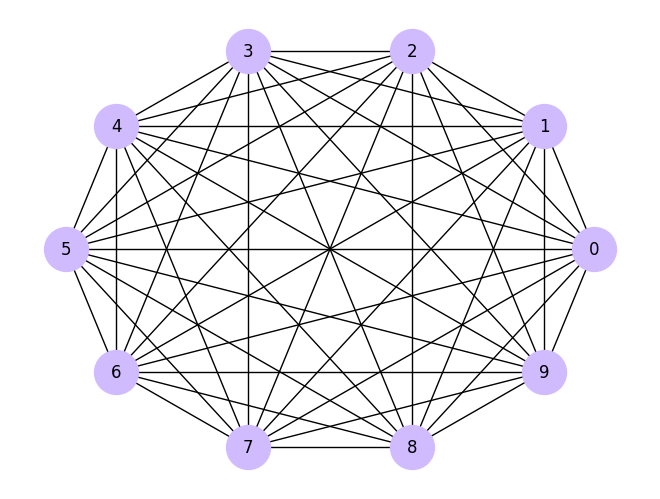

In [51]:
# Solution

colors = sns.color_palette('pastel', 5)
sns.set_palette(colors)

import random

def m_pairs(nodes, m):
    pairs = list(all_pairs(nodes))
    return random.sample(pairs, m)

def all_edges(nodes):
    for u in nodes:
        for v in nodes:
            if u < v:
                yield u, v

def m_pairs(nodes, m):
    n = len(nodes)
    num = m
    den = n * (n-1) / 2 
    for edge in all_edges(nodes):
        p = num / den
        print(p)
        if flip(p):
            num -= 1
            den -= 1
            yield edge
        else:
            den -= 1

def make_m_graph(n, m):
    G = nx.Graph()
    nodes = range(n)
    G.add_nodes_from(nodes)
    G.add_edges_from(m_pairs(nodes, m))
    return G

m_graph = make_m_graph(10, 47)

nx.draw_circular(m_graph, 
                 node_color='C4', 
                 node_size=1000, 
                 with_labels=True)

In [52]:
m_graph.number_of_edges()

45

In [53]:
# Solution

def prob_m_connected(n, m, iters=100):
    count = 0
    for i in range(iters):
        m_graph = make_m_graph(n, m)
        if is_connected(m_graph):
            count += 1
    return count/iters

n = 10
pstar = np.log(n) / n
ps = np.logspace(-1.3, 0, 11)
ms = [int(p * n * (n-1) / 2) for p in ps]
ys = [prob_m_connected(n, m, 100) for m in ms]

for p, m, y in zip(ps, ms, ys):
    print(p, m, y)

0.044444444444444446
0.022727272727272728
0.023255813953488372
0.023809523809523808
0.024390243902439025
0.025
0.02564102564102564
0.02631578947368421
0.02702702702702703
0.027777777777777776
0.02857142857142857
0.029411764705882353
0.030303030303030304
0.03125
0.03225806451612903
0.03333333333333333
0.034482758620689655
0.03571428571428571
0.037037037037037035
0.038461538461538464
0.04
0.041666666666666664
0.043478260869565216
0.045454545454545456
0.047619047619047616
0.05
0.05263157894736842
0.05555555555555555
0.058823529411764705
0.0625
0.06666666666666667
0.07142857142857142
0.07692307692307693
0.08333333333333333
0.09090909090909091
0.1
0.1111111111111111
0.125
0.14285714285714285
0.16666666666666666
0.2
0.25
0.0
0.0
0.0
0.044444444444444446
0.045454545454545456
0.046511627906976744
0.047619047619047616
0.04878048780487805
0.05
0.05128205128205128
0.05263157894736842
0.02702702702702703
0.027777777777777776
0.02857142857142857
0.029411764705882353
0.030303030303030304
0.0
0.0
0.0


0.0
0.06666666666666667
0.06818181818181818
0.06976744186046512
0.07142857142857142
0.07317073170731707
0.075
0.07692307692307693
0.07894736842105263
0.08108108108108109
0.08333333333333333
0.08571428571428572
0.08823529411764706
0.09090909090909091
0.09375
0.0967741935483871
0.1
0.10344827586206896
0.10714285714285714
0.1111111111111111
0.11538461538461539
0.12
0.125
0.13043478260869565
0.09090909090909091
0.09523809523809523
0.1
0.05263157894736842
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.06666666666666667
0.06818181818181818
0.06976744186046512
0.07142857142857142
0.07317073170731707
0.075
0.07692307692307693
0.07894736842105263
0.08108108108108109
0.08333333333333333
0.08571428571428572
0.08823529411764706
0.09090909090909091
0.09375
0.0967741935483871
0.1
0.10344827586206896
0.10714285714285714
0.1111111111111111
0.11538461538461539
0.12
0.125
0.13043478260869565
0.13636363636363635
0.14285714285714285
0.15
0.15789473684210525
0.16666666666666666



0.13333333333333333
0.14285714285714285
0.15384615384615385
0.16666666666666666
0.18181818181818182
0.2
0.2222222222222222
0.25
0.14285714285714285
0.16666666666666666
0.0
0.0
0.0
0.0
0.0
0.1111111111111111
0.11363636363636363
0.11627906976744186
0.09523809523809523
0.0975609756097561
0.1
0.10256410256410256
0.07894736842105263
0.08108108108108109
0.08333333333333333
0.08571428571428572
0.058823529411764705
0.06060606060606061
0.0625
0.06451612903225806
0.06666666666666667
0.06896551724137931
0.07142857142857142
0.07407407407407407
0.07692307692307693
0.08
0.08333333333333333
0.08695652173913043
0.09090909090909091
0.09523809523809523
0.1
0.10526315789473684
0.1111111111111111
0.11764705882352941
0.125
0.13333333333333333
0.14285714285714285
0.15384615384615385
0.16666666666666666
0.18181818181818182
0.2
0.2222222222222222
0.25
0.2857142857142857
0.3333333333333333
0.2
0.25
0.3333333333333333
0.5
0.0
0.1111111111111111
0.11363636363636363
0.11627906976744186
0.11904761904761904
0.1219

0.375
0.358974358974359
0.34210526315789475
0.35135135135135137
0.3611111111111111
0.34285714285714286
0.35294117647058826
0.36363636363636365
0.34375
0.3548387096774194
0.3333333333333333
0.3448275862068966
0.32142857142857145
0.2962962962962963
0.3076923076923077
0.32
0.3333333333333333
0.34782608695652173
0.36363636363636365
0.38095238095238093
0.4
0.3684210526315789
0.3888888888888889
0.35294117647058826
0.375
0.4
0.42857142857142855
0.46153846153846156
0.5
0.45454545454545453
0.5
0.4444444444444444
0.375
0.42857142857142855
0.3333333333333333
0.4
0.5
0.6666666666666666
0.5
1.0
0.4
0.38636363636363635
0.3953488372093023
0.40476190476190477
0.4146341463414634
0.425
0.41025641025641024
0.42105263157894735
0.43243243243243246
0.4166666666666667
0.42857142857142855
0.4411764705882353
0.45454545454545453
0.46875
0.4838709677419355
0.5
0.5172413793103449
0.5357142857142857
0.5555555555555556
0.5384615384615384
0.52
0.5
0.4782608695652174
0.5
0.5238095238095238
0.55
0.5263157894736842
0.5

0.5555555555555556
0.5428571428571428
0.5588235294117647
0.5454545454545454
0.5625
0.5806451612903226
0.6
0.5862068965517241
0.5714285714285714
0.5925925925925926
0.6153846153846154
0.6
0.625
0.6086956521739131
0.5909090909090909
0.6190476190476191
0.6
0.5789473684210527
0.6111111111111112
0.5882352941176471
0.5625
0.6
0.5714285714285714
0.5384615384615384
0.5
0.5454545454545454
0.6
0.5555555555555556
0.5
0.5714285714285714
0.6666666666666666
0.8
1.0
1.0
1.0
1.0
0.5333333333333333
0.5454545454545454
0.5348837209302325
0.5238095238095238
0.5121951219512195
0.5
0.48717948717948717
0.47368421052631576
0.4594594594594595
0.4722222222222222
0.4857142857142857
0.5
0.48484848484848486
0.5
0.5161290322580645
0.5333333333333333
0.5517241379310345
0.5714285714285714
0.5555555555555556
0.5384615384615384
0.52
0.5
0.4782608695652174
0.5
0.5238095238095238
0.55
0.5789473684210527
0.5555555555555556
0.5294117647058824
0.5
0.4666666666666667
0.42857142857142855
0.38461538461538464
0.4166666666666667



1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0

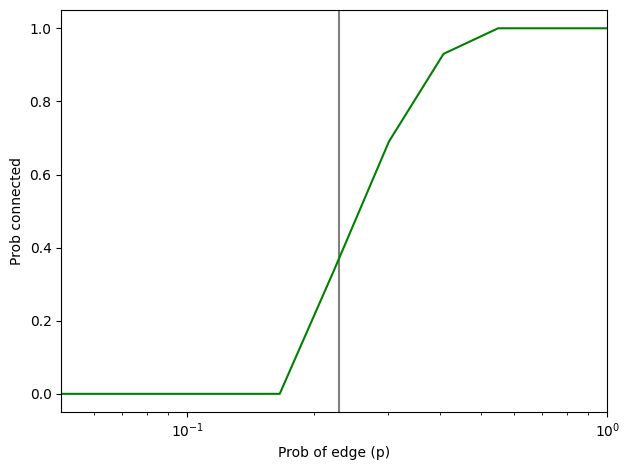

In [54]:
# Solution

plt.axvline(pstar, color='gray')
plt.plot(ps, ys, color='green')
decorate(xlabel='Prob of edge (p)',
         ylabel='Prob connected',
         xscale='log', 
         xlim=[ps[0], ps[-1]])

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)